# Transformer Models for IDA Price Forecasting

Two attention-based architectures compared against our existing models:

1. **Vanilla Transformer Encoder** — standard self-attention over temporal tokens
2. **iTransformer** (Liu et al., ICLR 2024) — inverted: attention over variate (feature) tokens

Both use Optuna hyperparameter optimization. Same data, same metrics, same test period.

Previous best results (Period A: Oct–Jan):
| Model | MAE t+1h | MAE t+2h | MAE t+3h |
|---|---|---|---|
| XGBoost | **15.90** | 17.88 | 18.98 |
| MLP | 17.12 | **17.05** | **17.80** |
| LSTM | 17.03 | 18.10 | 18.96 |
| Chronos | 17.00 | 21.17 | 23.20 |

In [ ]:
!pip install optuna -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, random, time, warnings

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.5 MB/s eta 0:00:00
Device: cpu


## 1. Data Loading (identical to main notebook)

In [ ]:
FILENAME = '/content/Final2026_with_ENTSOE.csv'

try:
    df = pd.read_csv(FILENAME, sep=',')
    if len(df.columns) == 1: df = pd.read_csv(FILENAME, sep=';')
except: df = pd.read_csv(FILENAME)

df = df.rename(columns={
    'Day time': 'DELIVERY_MTU', 'DAM price': 'DAM_MCP',
    'IDA1': 'MCP', 'IDA2': 'MCP_IDA2', 'IDA3': 'MCP_IDA3',
    'BM price': 'BM_IMBALANCE_PRICE', 'BMmDAM price': 'BMmDAMMCP',
})
df['DELIVERY_MTU'] = pd.to_datetime(df['DELIVERY_MTU'])
df = df.sort_values('DELIVERY_MTU').reset_index(drop=True)

df['hour'] = df['DELIVERY_MTU'].dt.hour
df['minute'] = df['DELIVERY_MTU'].dt.minute / 60.0
df['dayofweek'] = df['DELIVERY_MTU'].dt.dayofweek
df['ida3_available'] = df['MCP_IDA3'].notna().astype(float)
df['MCP_IDA3'] = df['MCP_IDA3'].fillna(0.0)
df['MCP_IDA2'] = df['MCP_IDA2'].ffill().bfill().fillna(0.0)
df['MCP'] = df['MCP'].ffill().bfill().fillna(df['MCP_IDA2'])
df['DAM_MCP'] = df['DAM_MCP'].ffill().bfill()
df['BMmDAMMCP'] = df['BMmDAMMCP'].ffill().bfill().fillna(0.0)
df['BM_IMBALANCE_PRICE'] = df['BM_IMBALANCE_PRICE'].ffill().bfill().fillna(df['BM_IMBALANCE_PRICE'].median())
df['IDA_target'] = np.where(df['ida3_available'] == 1, df['MCP_IDA3'], df['MCP_IDA2'])
df['ISP2_RES'] = df['ISP2_RES'].ffill().bfill().fillna(df['ISP1_RES'])
df['ISP2_Load'] = df['ISP2_Load'].ffill().bfill().fillna(df['ISP1_Load'])

df['DA_RES'] = df['Wind_DA_forecast'] + df['Solar_DA_forecast']
is_ida3 = df['hour'] >= 12
df['latest_RES'] = np.where(is_ida3, df['ISP3_RES'], df['ISP2_RES'])
df['latest_Load'] = np.where(is_ida3, df['ISP3_Load'], df['ISP2_Load'])
df['latest_RES_revision'] = df['latest_RES'] - df['DA_RES']
df['latest_Load_revision'] = df['latest_Load'] - df['SystemLoad_DA_forecast']
df['latest_net_load'] = df['latest_Load'] - df['latest_RES']
df['DA_net_load'] = df['SystemLoad_DA_forecast'] - df['DA_RES']
df['latest_net_load_revision'] = df['latest_net_load'] - df['DA_net_load']
df['RES_revision_ISP2_to_ISP3'] = np.where(is_ida3, df['ISP3_RES'] - df['ISP2_RES'], 0.0)
df['Load_revision_ISP2_to_ISP3'] = np.where(is_ida3, df['ISP3_Load'] - df['ISP2_Load'], 0.0)

df['bm_roll_mean_4'] = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).mean()
df['bm_roll_std_4'] = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).std().fillna(0)
df['bm_roll_mean_12'] = df['BM_IMBALANCE_PRICE'].rolling(12, min_periods=1).mean()
df['ida_momentum'] = df['MCP_IDA2'].diff(4).fillna(0)
df['mcp_momentum'] = df['MCP'].diff(4).fillna(0)
df['bm_momentum'] = df['BM_IMBALANCE_PRICE'].diff(4).fillna(0)
df['bm_ida_spread'] = df['BM_IMBALANCE_PRICE'] - df['MCP_IDA2']
df['ida_roll_std_4'] = df['MCP_IDA2'].rolling(4, min_periods=1).std().fillna(0)

for h_steps, h_name in [(4, '1h'), (8, '2h'), (12, '3h')]:
    df[f'IDA_target_{h_name}'] = df['IDA_target'].shift(-h_steps)
    df[f'ida3_at_{h_name}'] = (df['hour'].shift(-h_steps) >= 12).astype(float)

df = df.dropna(subset=['IDA_target_1h', 'IDA_target_2h', 'IDA_target_3h']).reset_index(drop=True)
df = df[df['DELIVERY_MTU'] >= '2025-10-02'].copy().reset_index(drop=True)
df = df[df['DELIVERY_MTU'] <= '2026-01-18 23:45:00'].copy().reset_index(drop=True)

FEATURES = [
    'MCP', 'MCP_IDA2', 'DAM_MCP',
    'BM_IMBALANCE_PRICE', 'bm_roll_mean_4', 'bm_roll_std_4', 'bm_roll_mean_12', 'bm_ida_spread',
    'ida_momentum', 'mcp_momentum', 'bm_momentum', 'ida_roll_std_4',
    'SystemLoad_DA_forecast', 'Wind_DA_forecast', 'Solar_DA_forecast',
    'ida3_available', 'ida3_at_1h', 'ida3_at_2h', 'ida3_at_3h',
    'hour', 'minute', 'dayofweek',
    'latest_RES', 'latest_Load',
    'latest_RES_revision', 'latest_Load_revision', 'latest_net_load_revision', 'latest_net_load',
    'RES_revision_ISP2_to_ISP3', 'Load_revision_ISP2_to_ISP3',
]
TARGETS = ['IDA_target_1h', 'IDA_target_2h', 'IDA_target_3h']
HORIZON = 3; BATCH = 64; TRAIN_RATIO = 0.8
N_FEAT = len(FEATURES)
split_idx = int(len(df) * TRAIN_RATIO)

df[FEATURES] = df[FEATURES].ffill().bfill().fillna(0)

scaler_X = MinMaxScaler()
data_X = df[FEATURES].values.astype(np.float32)
scaler_X.fit(data_X[:split_idx])
data_X_sc = scaler_X.transform(data_X)

scaler_y = MinMaxScaler()
all_tgt = df[TARGETS].values.astype(np.float32)
scaler_y.fit(all_tgt[:split_idx].reshape(-1, 1))
tgt_sc = np.zeros((len(df), HORIZON), dtype=np.float32)
for h in range(HORIZON):
    tgt_sc[:, h] = scaler_y.transform(df[TARGETS[h]].values.astype(np.float32).reshape(-1,1)).flatten()

print(f"Dataset: {df.shape}, Features: {N_FEAT}, Train: {split_idx}, Test: {len(df)-split_idx}")

Dataset: (10464, 45), Features: 30, Train: 8371, Test: 2093


## 2. Model Definitions

### Vanilla Transformer Encoder
Standard approach: each timestep is a token, self-attention captures temporal dependencies.

### iTransformer (Liu et al., ICLR 2024)
Inverted approach: each **feature** is a token (length = lookback). Attention captures **multivariate correlations** instead of temporal correlations. Feed-forward learns nonlinear representations per variate.

In [ ]:
class SeqDataset(Dataset):
    def __init__(self, X, y, lb):
        self.X, self.y, self.lb = X, y, lb
    def __len__(self):
        return len(self.X) - self.lb
    def __getitem__(self, i):
        return (torch.tensor(self.X[i:i+self.lb], dtype=torch.float32),
                torch.tensor(self.y[i+self.lb], dtype=torch.float32))

# ── Positional Encoding ──
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# ── Vanilla Transformer Encoder ──
# Input: (batch, lookback, n_features) → tokens = timesteps
class TransformerForecaster(nn.Module):
    def __init__(self, n_feat, d_model, nhead, n_layers, dim_ff, horizon, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, horizon))

    def forward(self, x):
        # x: (batch, lookback, n_feat)
        x = self.input_proj(x)          # (batch, lookback, d_model)
        x = self.pos_enc(x)
        x = self.encoder(x)             # (batch, lookback, d_model)
        x = x[:, -1, :]                 # take last timestep
        return self.fc(x)               # (batch, horizon)

# ── iTransformer ──
# INVERTED: tokens = features, each token is the time series of that feature
# Input: (batch, lookback, n_features) → transpose → (batch, n_features, lookback)
class iTransformerForecaster(nn.Module):
    def __init__(self, n_feat, lookback, d_model, nhead, n_layers, dim_ff, horizon, dropout=0.1):
        super().__init__()
        # Each variate token: lookback values → d_model embedding
        self.variate_embed = nn.Linear(lookback, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        # Project all variate tokens → horizon predictions
        self.fc = nn.Sequential(
            nn.Linear(n_feat * d_model, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, horizon))

    def forward(self, x):
        # x: (batch, lookback, n_feat)
        x = x.permute(0, 2, 1)          # (batch, n_feat, lookback) — INVERTED
        x = self.variate_embed(x)        # (batch, n_feat, d_model) — each feature is a token
        x = self.encoder(x)              # (batch, n_feat, d_model) — attention across features
        x = x.flatten(1)                 # (batch, n_feat * d_model)
        return self.fc(x)                # (batch, horizon)

print(f"Models defined. Features: {N_FEAT}")

Models defined. Features: 30


## 3. Training Infrastructure

In [ ]:
def train_model(model, ld_tr, ld_te, epochs, lr, label=""):
    model = model.to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val = float('inf'); best_state = None

    for ep in range(1, epochs+1):
        model.train(); tl = 0
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
            tl += loss.item() * X.size(0)
        tl /= len(ld_tr.dataset)

        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        sched.step()

        if vl < best_val:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if ep % 30 == 0 or ep == 1:
            print(f"  [{label}] {ep:3d}/{epochs} | train: {tl:.6f} | val: {vl:.6f}")

    model.load_state_dict(best_state)
    print(f"  [{label}] Best: {best_val:.6f}")
    return best_val

def evaluate_model(model, dataset, scaler_y, horizon):
    model.eval()
    preds_all, acts_all = [], []
    with torch.no_grad():
        for X, y in DataLoader(dataset, batch_size=256, shuffle=False):
            preds_all.append(model(X.to(device)).cpu().numpy())
            acts_all.append(y.numpy())
    preds = np.concatenate(preds_all); acts = np.concatenate(acts_all)
    p_inv = np.zeros_like(preds); a_inv = np.zeros_like(acts)
    for h in range(horizon):
        p_inv[:, h] = scaler_y.inverse_transform(preds[:, h].reshape(-1,1)).flatten()
        a_inv[:, h] = scaler_y.inverse_transform(acts[:, h].reshape(-1,1)).flatten()
    return p_inv, a_inv

print("Training infrastructure ready")

Training infrastructure ready


## 4. Optuna — Vanilla Transformer

In [ ]:
SEARCH_EPOCHS = 50

def transformer_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48])
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dim_ff = trial.suggest_categorical('dim_ff', [64, 128, 256])
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.1)

    # Ensure d_model divisible by nhead
    if d_model % nhead != 0:
        return float('inf')

    tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED)
    model = TransformerForecaster(N_FEAT, d_model, nhead, n_layers, dim_ff, HORIZON, dropout).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        model.train()
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running Transformer Optuna (30 trials)...")
tf_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
tf_study.optimize(transformer_objective, n_trials=30, show_progress_bar=True)
bp_tf = tf_study.best_trial.params
print(f"Transformer best: {bp_tf}, val_loss={tf_study.best_trial.value:.6f}")

Running Transformer Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Transformer best: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.00044061566611319574, 'dropout': 0.2}, val_loss=0.028090


## 5. Optuna — iTransformer

In [ ]:
def itransformer_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48])
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dim_ff = trial.suggest_categorical('dim_ff', [64, 128, 256])
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.1)

    if d_model % nhead != 0:
        return float('inf')

    tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED)
    model = iTransformerForecaster(N_FEAT, lb, d_model, nhead, n_layers, dim_ff, HORIZON, dropout).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        model.train()
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running iTransformer Optuna (30 trials)...")
it_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
it_study.optimize(itransformer_objective, n_trials=30, show_progress_bar=True)
bp_it = it_study.best_trial.params
print(f"iTransformer best: {bp_it}, val_loss={it_study.best_trial.value:.6f}")

Running iTransformer Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

iTransformer best: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.0016923190258501973, 'dropout': 0.3}, val_loss=0.027992


In [ ]:
# Hardcoded from Optuna runs
bp_it = {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.001692, 'dropout': 0.3}
bp_tf = {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.000441, 'dropout': 0.2}
print(f"iTransformer: {bp_it}")
print(f"Transformer:  {bp_tf}")

iTransformer: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.001692, 'dropout': 0.3}
Transformer:  {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.000441, 'dropout': 0.2}


## 6. Train Final Models

In [ ]:
EPOCHS = 120
results = {}

# ── Vanilla Transformer ──
print("=" * 60)
print(f"Transformer: {bp_tf}")
lb = bp_tf['lookback']
tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED)
model_tf = TransformerForecaster(N_FEAT, bp_tf['d_model'], bp_tf['nhead'],
    bp_tf['n_layers'], bp_tf['dim_ff'], HORIZON, bp_tf['dropout'])
train_model(model_tf, DataLoader(tr, batch_size=BATCH, shuffle=True),
            DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_tf['lr'], "Transformer")
preds_tf, acts_tf = evaluate_model(model_tf, te, scaler_y, HORIZON)
results['Transformer'] = preds_tf

# ── iTransformer ──
print("=" * 60)
print(f"iTransformer: {bp_it}")
lb = bp_it['lookback']
tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED)
model_it = iTransformerForecaster(N_FEAT, lb, bp_it['d_model'], bp_it['nhead'],
    bp_it['n_layers'], bp_it['dim_ff'], HORIZON, bp_it['dropout'])
train_model(model_it, DataLoader(tr, batch_size=BATCH, shuffle=True),
            DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_it['lr'], "iTransformer")
preds_it, acts_it = evaluate_model(model_it, te, scaler_y, HORIZON)
results['iTransformer'] = preds_it

print("Both models trained.")

Transformer: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.000441, 'dropout': 0.2}
  [Transformer]   1/120 | train: 0.096645 | val: 0.043474
  [Transformer]  30/120 | train: 0.034945 | val: 0.028844
  [Transformer]  60/120 | train: 0.032584 | val: 0.030213
  [Transformer]  90/120 | train: 0.031138 | val: 0.029872
  [Transformer] 120/120 | train: 0.030953 | val: 0.030255
  [Transformer] Best: 0.028531
iTransformer: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.001692, 'dropout': 0.3}
  [iTransformer]   1/120 | train: 0.095704 | val: 0.036410
  [iTransformer]  30/120 | train: 0.031743 | val: 0.033020
  [iTransformer]  60/120 | train: 0.027122 | val: 0.031690
  [iTransformer]  90/120 | train: 0.024523 | val: 0.031580
  [iTransformer] 120/120 | train: 0.023751 | val: 0.031487
  [iTransformer] Best: 0.028217
Both models trained.


## 7. Full Comparison

In [ ]:
horizon_names = ['1h', '2h', '3h']
n_test = min(len(p) for p in results.values())
naive_vals = df['IDA_target'].values[split_idx:split_idx+n_test]

# All previous results (Period A)
prev = {
    'XGBoost':  [15.90, 17.88, 18.98],
    'MLP':      [17.12, 17.05, 17.80],
    'LSTM':     [17.03, 18.10, 18.96],
    'Chronos':  [17.00, 21.17, 23.20],
    'TabPFN':   [18.58, 22.36, 24.40],
}

print("  FULL COMPARISON: All Models (Period A: Oct-Jan)")
print(f"  {'Model':<16} {'MAE-1h':>8} {'MAE-2h':>8} {'MAE-3h':>8} {'FSI-1h':>8} {'FSI-2h':>8} {'FSI-3h':>8}")
print(f"  {'='*60}")

# New transformer models
for name, preds in results.items():
    acts = acts_tf if name == 'Transformer' else acts_it
    print(f"  {name:<16}", end="")
    for h in range(HORIZON):
        mae = mean_absolute_error(acts[-n_test:, h], preds[-n_test:, h])
        naive_mae = mean_absolute_error(acts[-n_test:, h], naive_vals)
        fsi = (1 - mae / naive_mae) * 100
        print(f" {mae:>8.2f}", end="")
    # FSI
    for h in range(HORIZON):
        mae = mean_absolute_error(acts[-n_test:, h], preds[-n_test:, h])
        naive_mae = mean_absolute_error(acts[-n_test:, h], naive_vals)
        fsi = (1 - mae / naive_mae) * 100
        print(f" {fsi:>+7.1f}%", end="")
    print()

# Previous models
for name, maes in prev.items():
    print(f"  {name:<16}", end="")
    for h in range(HORIZON):
        print(f" {maes[h]:>8.2f}", end="")
    print(f" {'---':>8} {'---':>8} {'---':>8}")

# Naive
naive_mae_1h = mean_absolute_error(acts_tf[-n_test:, 0], naive_vals)
print(f"  {'Naive':<16} {naive_mae_1h:>8.2f} {'---':>8} {'---':>8} {'0.0%':>8} {'0.0%':>8} {'0.0%':>8}")

  FULL COMPARISON: All Models (Period A: Oct-Jan)
  Model              MAE-1h   MAE-2h   MAE-3h   FSI-1h   FSI-2h   FSI-3h
  Transformer         16.15    17.48    18.18    +6.9%   +31.6%   +42.2%
  iTransformer        15.90    17.20    18.14    +8.3%   +32.7%   +42.4%
  XGBoost             15.90    17.88    18.98      ---      ---      ---
  MLP                 17.12    17.05    17.80      ---      ---      ---
  LSTM                17.03    18.10    18.96      ---      ---      ---
  Chronos             17.00    21.17    23.20      ---      ---      ---
  TabPFN              18.58    22.36    24.40      ---      ---      ---
  Naive               17.34      ---      ---     0.0%     0.0%     0.0%


In [ ]:
# Compact MAE table for thesis
print("\n  MAE Summary — All Models (Period A)")
print(f"  {'Model':<20} {'t+1h':>8} {'t+2h':>8} {'t+3h':>8}")
print(f"  {'-'*46}")

# Compute transformer MAEs
all_maes = {}
for name, preds in results.items():
    acts = acts_tf if name == 'Transformer' else acts_it
    maes = []
    for h in range(HORIZON):
        maes.append(mean_absolute_error(acts[-n_test:, h], preds[-n_test:, h]))
    all_maes[name] = maes

# Print sorted by t+1h
all_models = {**{k: v for k, v in all_maes.items()}, **prev}
for name in sorted(all_models, key=lambda x: all_models[x][0]):
    maes = all_models[name]
    print(f"  {name:<20} {maes[0]:>8.2f} {maes[1]:>8.2f} {maes[2]:>8.2f}")

print(f"  {'Naive':<20} {naive_mae_1h:>8.2f}     ---      ---")


  MAE Summary — All Models (Period A)
  Model                    t+1h     t+2h     t+3h
  ----------------------------------------------
  iTransformer            15.90    17.20    18.14
  XGBoost                 15.90    17.88    18.98
  Transformer             16.15    17.48    18.18
  Chronos                 17.00    21.17    23.20
  LSTM                    17.03    18.10    18.96
  MLP                     17.12    17.05    17.80
  TabPFN                  18.58    22.36    24.40
  Naive                   17.34     ---      ---


## 8. Prediction Plots

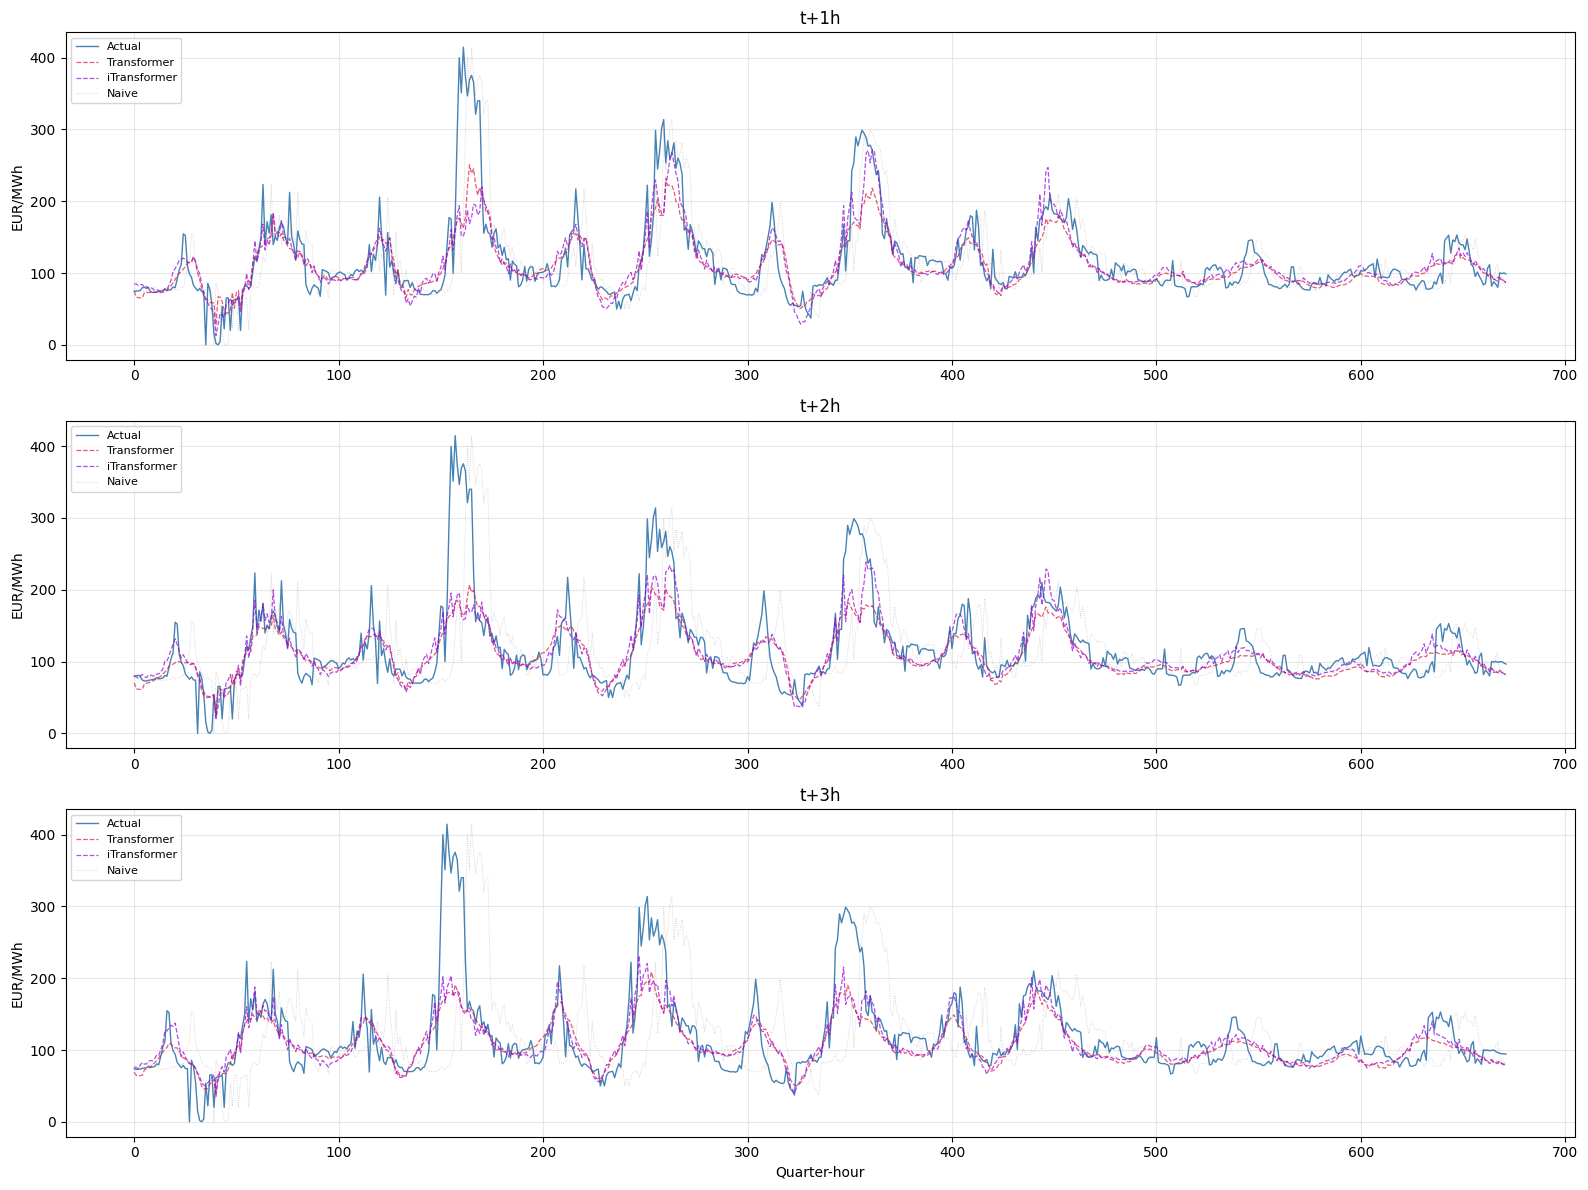

In [ ]:
N_PLOT = 96 * 7
colors = {'Transformer': 'crimson', 'iTransformer': 'darkviolet'}

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
for h, ax in enumerate(axes):
    ax.plot(acts_tf[-N_PLOT:, h], color='steelblue', linewidth=1, label='Actual')
    for name, preds in results.items():
        ax.plot(preds[-N_PLOT:, h], color=colors[name], linewidth=0.9,
                linestyle='--', alpha=0.7, label=name)
    ax.plot(naive_vals[-N_PLOT:], color='gray', linewidth=0.6,
            linestyle=':', alpha=0.4, label='Naive')
    ax.set_ylabel('EUR/MWh')
    ax.set_title(f't+{horizon_names[h]}')
    ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Quarter-hour')
plt.tight_layout(); plt.show()

NameError: name 'tf_study' is not defined

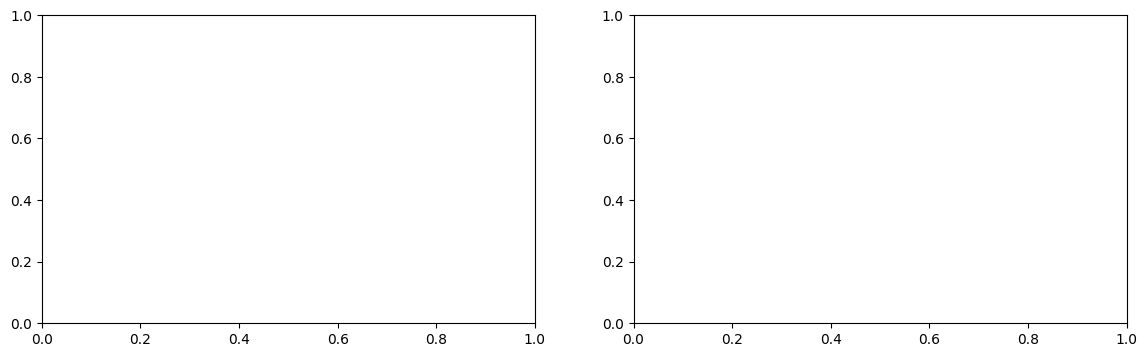

In [ ]:
# Optuna history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, study, name in zip(axes, [tf_study, it_study], ['Transformer', 'iTransformer']):
    vals = [t.value for t in study.trials if t.value and t.value < float('inf')]
    ax.plot(vals, 'o-', markersize=3, alpha=0.6)
    ax.axhline(min(vals), color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{name}: Optuna History'); ax.set_xlabel('Trial'); ax.set_ylabel('Val Loss')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Transformer best params: {bp_tf}")
print(f"iTransformer best params: {bp_it}")

## 9. Summary

| Model | Type | Attention Over | Key Idea |
|---|---|---|---|
| **Transformer** | Encoder | Timesteps | Standard: each timestep is a token |
| **iTransformer** | Inverted Encoder | Features | Liu et al. (ICLR 2024): each feature is a token |

The **iTransformer** treats each of the 30 features as a token of length `lookback`. Self-attention then captures correlations between features (e.g., "when ISP revision goes up AND BM goes down, prices drop"). This is fundamentally different from the vanilla Transformer which captures temporal patterns within the sequence.

Both models complement the existing comparison:
- **LSTM**: sequential temporal modeling
- **MLP**: flattened feature vector
- **XGBoost**: tree-based feature interactions
- **Transformer**: temporal attention
- **iTransformer**: variate attention